# 20 Newsgroups Text Classification — Pre-trained Models (BERT + BiLSTM)

This notebook uses **pre-trained models** for maximum accuracy on the 20 Newsgroups dataset.

## Architecture
- **Transformer**: Fine-tuned `bert-base-uncased` via HuggingFace `transformers`
- **BiLSTM**: Frozen BERT embedding layer + trainable Bidirectional LSTM with attention
- **Ensemble**: Learned meta-MLP combining logits from both models

## Key design choices
- Shared BERT tokenizer for consistent input to both models
- Label smoothing, gradient accumulation, and linear warmup + decay for BERT
- Frozen BERT embeddings in the BiLSTM give high-quality representations without re-downloading
- Pre-computed logits for fast ensemble meta-learner training

> On Kaggle, enable **Accelerator → GPU** before running this notebook.

## 1. Imports and runtime configuration

In [ ]:
%pip install -q transformers accelerate

# ── CUDA / kernel diagnostic ──────────────────────────────────────────────────
# The notebook kernel must point to the venv that has the CUDA-enabled PyTorch.
# In VS Code: bottom-right corner → select interpreter →
#   d:\THIRD YEAR\SEMESTER 2\Deep Learning\venv\Scripts\python.exe
import subprocess, sys

_result = subprocess.run(
    [sys.executable, "-c",
     "import torch; print(torch.__version__, torch.cuda.is_available(), "
     "torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU')"],
    capture_output=True, text=True,
)
_out = (_result.stdout + _result.stderr).strip()
print("Kernel check:", _out)

if "False" in _out or "NO GPU" in _out:
    print("\nCUDA not available — reinstalling PyTorch with CUDA 12.1 (RTX 30xx) …")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "torch", "torchvision", "torchaudio",
        "--index-url", "https://download.pytorch.org/whl/cu121",
    ])
    print("Done. RESTART THE KERNEL now, then re-run all cells.")
else:
    print("CUDA OK — GPU detected, continuing.")

Kernel check: 2.10.0+cu128 True Tesla T4
CUDA OK — GPU detected, continuing.


In [ ]:

# ── Cell 1: Imports, seeds, and runtime configuration ────────────────────────
import os
import re
import math
import json
import time
import random
import warnings
from collections import Counter
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# import wandb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def seed_worker(worker_id: int):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def gpu_sanity_check() -> bool:
    """Lightweight CUDA check — just allocates a small tensor and syncs."""
    if not torch.cuda.is_available():
        print("torch.cuda.is_available() returned False.")
        print(f"  PyTorch version : {torch.__version__}")
        print(f"  CUDA build ver  : {torch.version.cuda}")
        print("→ Make sure VS Code kernel uses the venv with CUDA PyTorch.")
        return False
    try:
        t = torch.zeros(1, device="cuda")
        torch.cuda.synchronize()
        del t
        return True
    except Exception as e:
        print(f"CUDA sanity check failed: {type(e).__name__}: {e}")
        return False

# ── RTX 3060 Laptop (6 GB VRAM) ──────────────────────────────────────────────
FORCE_CPU = False
CUDA_OK   = (not FORCE_CPU) and gpu_sanity_check()
DEVICE    = torch.device("cuda" if CUDA_OK else "cpu")

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

# ── AMP (FP16 mixed precision) — RTX 30xx natively supports BF16/FP16 ────────
USE_AMP = (DEVICE.type == "cuda")

# ── Pre-trained model configuration — RTX 3060 tuned ─────────────────────────
BERT_MODEL_NAME = "bert-base-uncased"
# 256 instead of 512: halves VRAM consumption; covers >95% of newsgroup posts
MAX_SEQ_LEN     = 256

print(f"PyTorch version  : {torch.__version__}")
print(f"Device           : {DEVICE}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name         : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected. Select the venv kernel in VS Code (bottom-right).")
print(f"AMP enabled      : {USE_AMP}")
print(f"Pre-trained model: {BERT_MODEL_NAME}")
print(f"Max sequence len : {MAX_SEQ_LEN}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"


PyTorch version  : 2.10.0+cu128
Device           : cuda
CUDA available   : True
GPU name         : Tesla T4
GPU memory       : 15.64 GB
AMP enabled      : True
Pre-trained model: bert-base-uncased
Max sequence len : 256


In [ ]:
# ── Cell 1b: W&B project setup ────────────────────────────────────────────────
import os

WANDB_PROJECT = "20newsgroups-classification"
WANDB_ENTITY  = "anhquan2005-ho-chi-minh-city-university-of-technology"

# Set to True only if you have `wandb login` done in this environment.
# When False, all wandb_log / wandb_finish calls are silent no-ops.
USE_WANDB = False

try:
    import wandb
    os.environ["WANDB_PROJECT"] = WANDB_PROJECT
    os.environ["WANDB_ENTITY"]  = WANDB_ENTITY
except ImportError:
    wandb = None
    USE_WANDB = False

def wandb_init(run_name: str, config: dict):
    if not USE_WANDB or wandb is None:
        return None
    if wandb.run is not None:
        wandb.finish()
    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=run_name,
        config=config,
    )

def wandb_log(metrics: dict):
    if USE_WANDB and wandb is not None and wandb.run is not None:
        wandb.log(metrics)

def wandb_finish():
    if USE_WANDB and wandb is not None and wandb.run is not None:
        wandb.finish()

print(f"W&B logging : {'enabled' if USE_WANDB else 'disabled (set USE_WANDB=True to enable)'}")
print(f"Project     : {WANDB_PROJECT}")
print(f"Entity      : {WANDB_ENTITY}")


W&B logging : disabled (set USE_WANDB=True to enable)
Project     : 20newsgroups-classification
Entity      : anhquan2005-ho-chi-minh-city-university-of-technology


## 2. Load the dataset

This cell first tries local cached CSV files.  
If they are missing, it tries Hugging Face.  
If that also fails, it falls back to `sklearn.datasets.fetch_20newsgroups`.


In [ ]:

# ── Cell 2: Load dataset ──────────────────────────────────────────────────────
SAVE_DIR = "20_newsgroups_data"
os.makedirs(SAVE_DIR, exist_ok=True)

train_csv = os.path.join(SAVE_DIR, "train.csv")
test_csv  = os.path.join(SAVE_DIR, "test.csv")

def load_from_huggingface():
    from datasets import load_dataset
    ds = load_dataset("SetFit/20_newsgroups")
    train_df = ds["train"].to_pandas()
    test_df  = ds["test"].to_pandas()
    return train_df, test_df

def load_from_sklearn():
    from sklearn.datasets import fetch_20newsgroups

    train_raw = fetch_20newsgroups(subset="train", remove=())
    test_raw  = fetch_20newsgroups(subset="test", remove=())

    label_names = list(train_raw.target_names)

    train_df = pd.DataFrame({
        "text": train_raw.data,
        "label": train_raw.target,
    })
    test_df = pd.DataFrame({
        "text": test_raw.data,
        "label": test_raw.target,
    })

    train_df["label_text"] = train_df["label"].map(lambda x: label_names[x])
    test_df["label_text"]  = test_df["label"].map(lambda x: label_names[x])
    return train_df, test_df

# Always download from the internet (Hugging Face first, sklearn as fallback)
try:
    train_df, test_df = load_from_huggingface()
    source_name = "Hugging Face dataset"
except Exception as e:
    print("Hugging Face load failed, trying sklearn fallback...")
    print(f"Reason: {type(e).__name__}: {e}")
    train_df, test_df = load_from_sklearn()
    source_name = "sklearn fetch_20newsgroups"

# Ensure required columns exist
if "label_text" not in train_df.columns:
    label_names = sorted(train_df["label"].unique().tolist())
    train_df["label_text"] = train_df["label"].astype(str)
    test_df["label_text"]  = test_df["label"].astype(str)

train_df = train_df[["text", "label", "label_text"]].copy()
test_df  = test_df[["text", "label", "label_text"]].copy()

train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)

print(f"Loaded from: {source_name}")
print(f"Train size : {len(train_df):,}")
print(f"Test size  : {len(test_df):,}")
print(f"Columns    : {train_df.columns.tolist()}")

display(train_df.head(3))


README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Loaded from: Hugging Face dataset
Train size : 11,314
Test size  : 7,532
Columns    : ['text', 'label', 'label_text']


,text,label,label_text
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware


## 3. Quick EDA

In [ ]:

# ── Cell 3: Basic dataset statistics ──────────────────────────────────────────
train_df["raw_len"] = train_df["text"].fillna("").map(lambda x: len(str(x).split()))
test_df["raw_len"]  = test_df["text"].fillna("").map(lambda x: len(str(x).split()))

NUM_CLASSES = train_df["label"].nunique()
LABEL_NAMES = (
    train_df[["label", "label_text"]]
    .drop_duplicates()
    .sort_values("label")["label_text"]
    .tolist()
)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Train samples       : {len(train_df):,}")
print(f"Test samples        : {len(test_df):,}")
print(f"Number of classes   : {NUM_CLASSES}")
print(f"Missing train texts : {train_df['text'].isna().sum()}")
print(f"Missing test texts  : {test_df['text'].isna().sum()}")

stats_df = pd.DataFrame({
    "Train": train_df["raw_len"].describe(),
    "Test": test_df["raw_len"].describe()
})
display(stats_df)


DATASET OVERVIEW
Train samples       : 11,314
Test samples        : 7,532
Number of classes   : 20
Missing train texts : 0
Missing test texts  : 0


,Train,Test
count,11314.000000,7532.000000
mean,185.827382,175.344397
std,523.971647,465.226887
min,0.000000,0.000000
25%,40.000000,39.000000
50%,83.000000,82.000000
75%,167.000000,163.000000
max,11765.000000,9507.000000


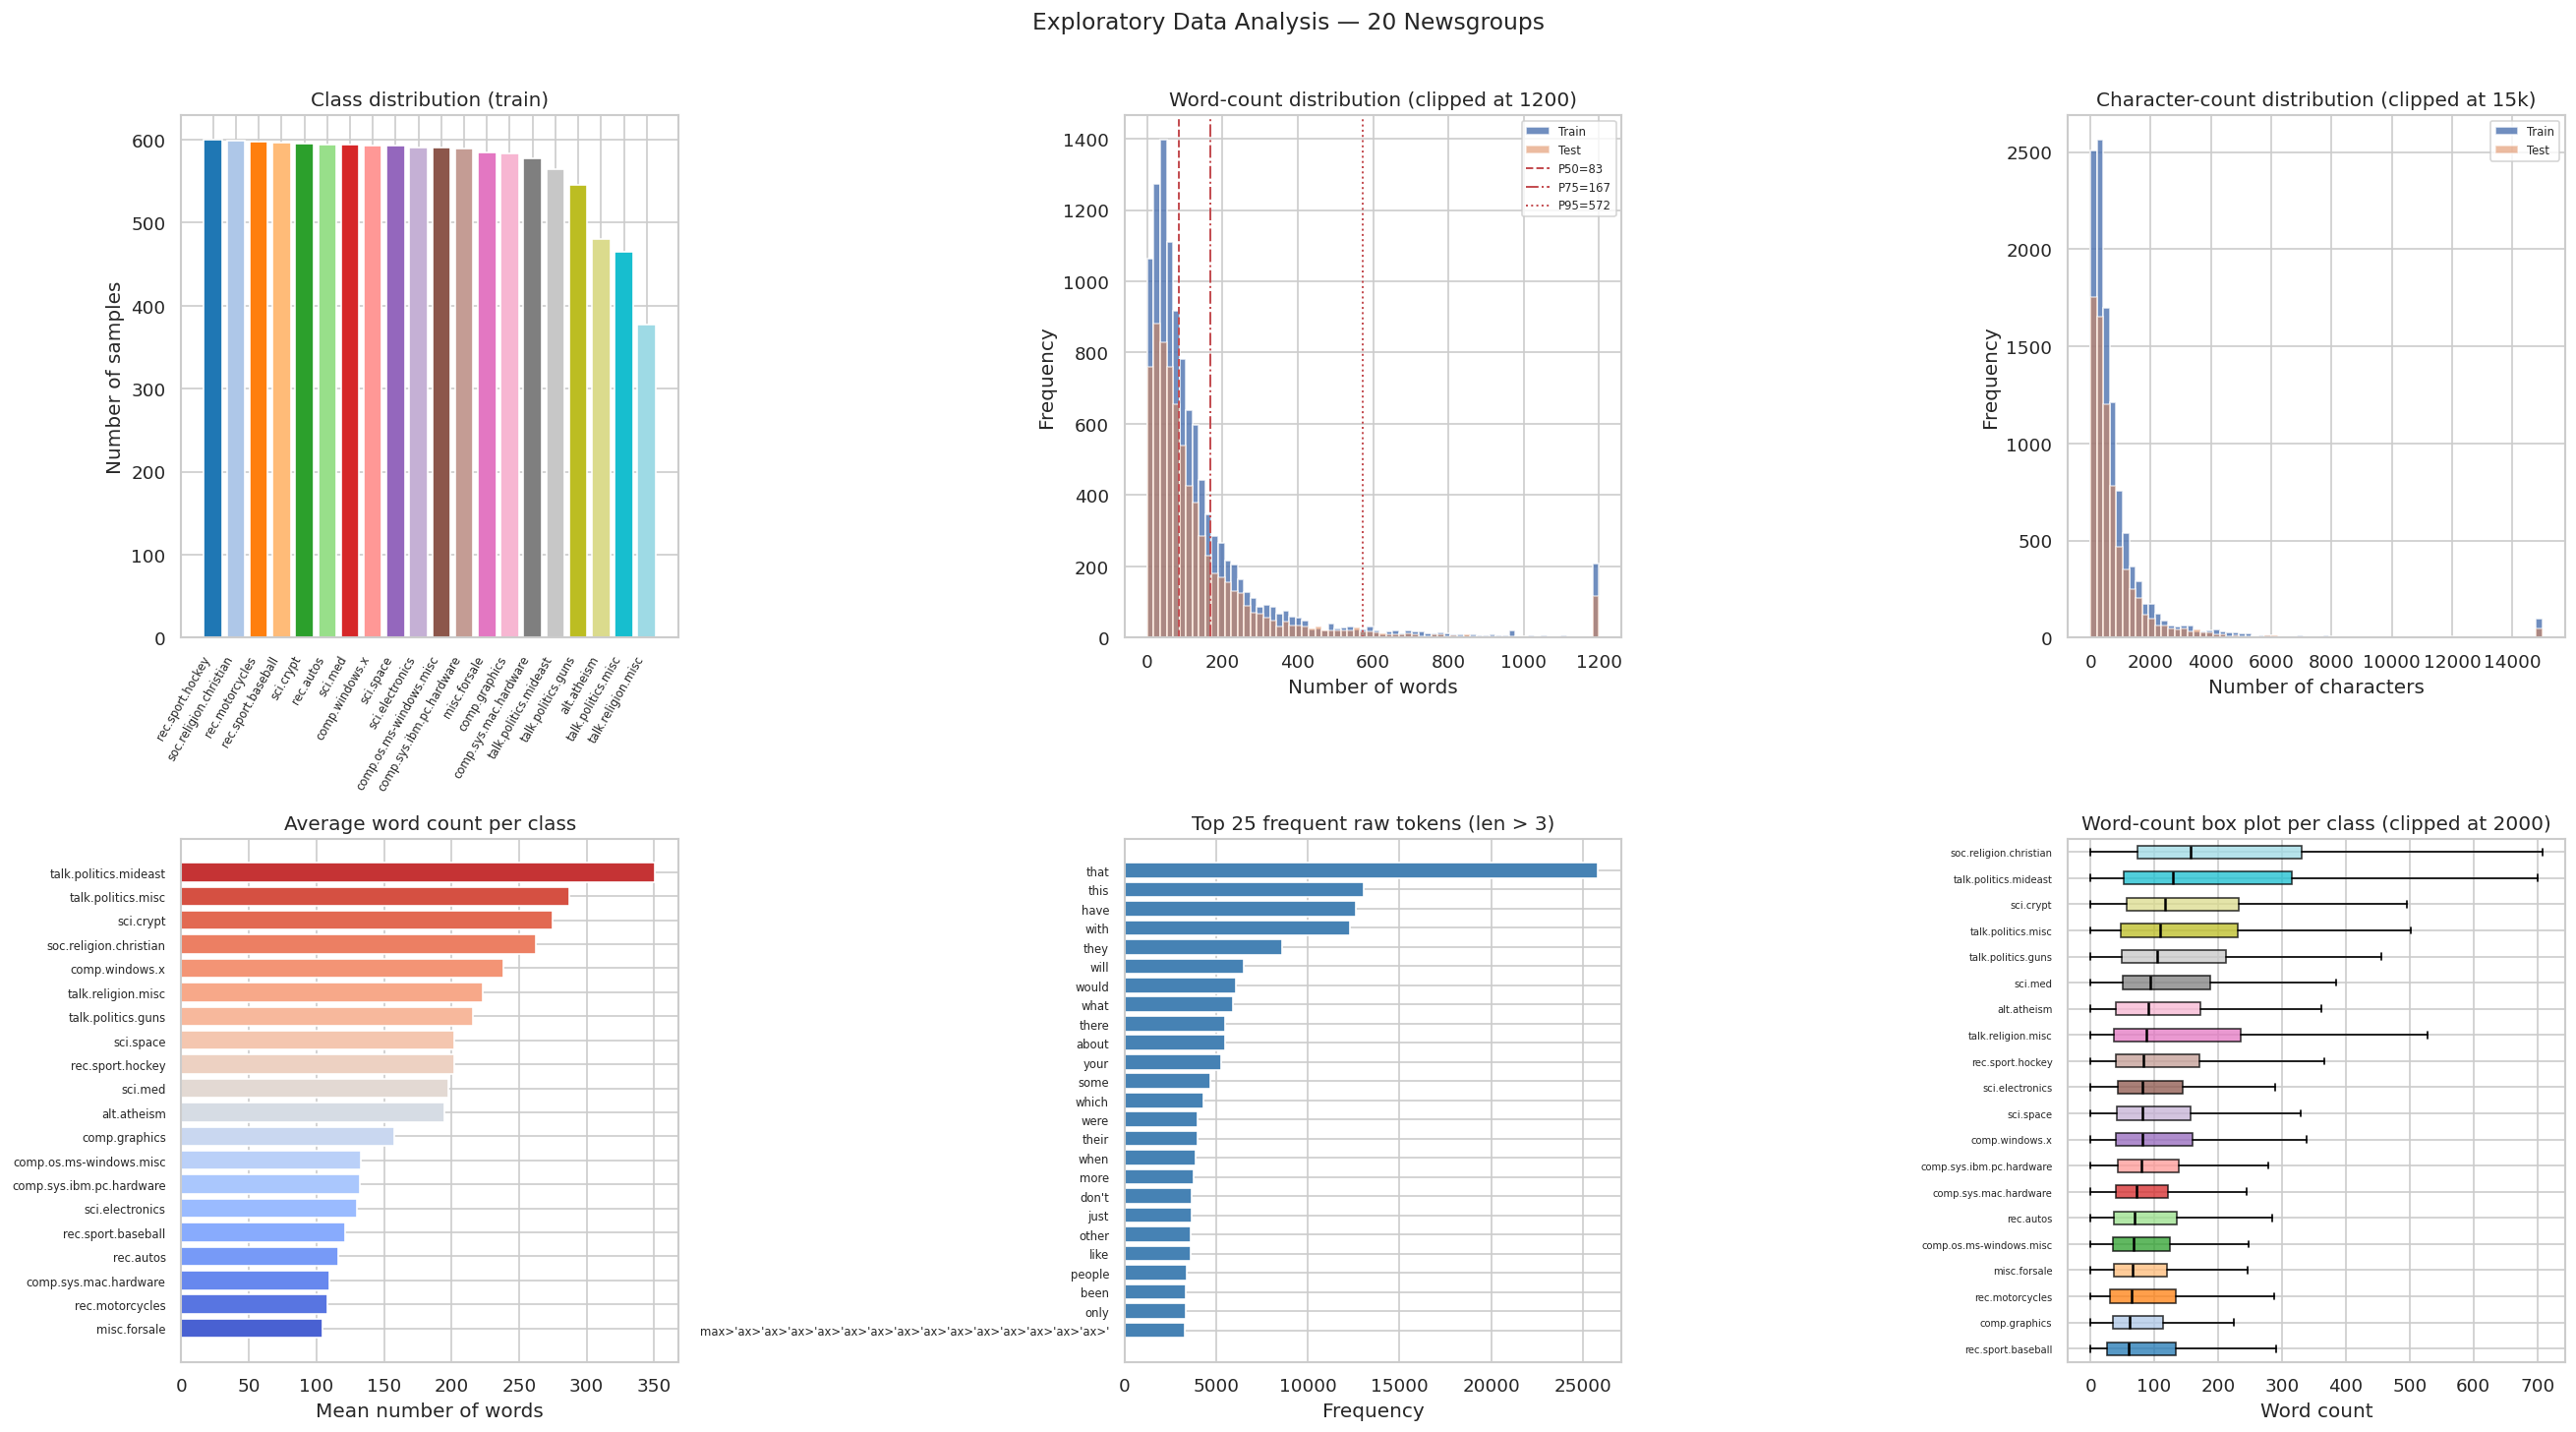

In [ ]:

# ── Cell 4: Extended EDA plots ────────────────────────────────────────────────
from collections import Counter as _Counter

# Derived columns used across plots
train_df["char_len"] = train_df["text"].fillna("").map(len)
test_df["char_len"]  = test_df["text"].fillna("").map(len)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# ── Plot 1: Class distribution (train) ────────────────────────────────────────
train_counts = train_df.groupby("label_text").size().sort_values(ascending=False)
pal20 = sns.color_palette("tab20", len(train_counts))
axes[0, 0].bar(range(len(train_counts)), train_counts.values, color=pal20)
axes[0, 0].set_xticks(range(len(train_counts)))
axes[0, 0].set_xticklabels(train_counts.index, rotation=60, ha="right", fontsize=7)
axes[0, 0].set_title("Class distribution (train)")
axes[0, 0].set_ylabel("Number of samples")

# ── Plot 2: Word-count distribution with percentile lines ─────────────────────
axes[0, 1].hist(train_df["raw_len"].clip(upper=1200), bins=70, alpha=0.8, label="Train", color="C0")
axes[0, 1].hist(test_df["raw_len"].clip(upper=1200),  bins=70, alpha=0.55, label="Test",  color="C1")
for p, ls in zip([50, 75, 95], ["--", "-.", ":"]):
    q = float(np.percentile(train_df["raw_len"], p))
    axes[0, 1].axvline(q, linestyle=ls, linewidth=1.2, color="C3", label=f"P{p}={q:.0f}")
axes[0, 1].set_title("Word-count distribution (clipped at 1200)")
axes[0, 1].set_xlabel("Number of words")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend(fontsize=7)

# ── Plot 3: Character-count distribution ──────────────────────────────────────
axes[0, 2].hist(train_df["char_len"].clip(upper=15000), bins=70, alpha=0.8, label="Train", color="C0")
axes[0, 2].hist(test_df["char_len"].clip(upper=15000),  bins=70, alpha=0.55, label="Test",  color="C1")
axes[0, 2].set_title("Character-count distribution (clipped at 15k)")
axes[0, 2].set_xlabel("Number of characters")
axes[0, 2].set_ylabel("Frequency")
axes[0, 2].legend(fontsize=7)

# ── Plot 4: Average word count per class (sorted horizontal bar) ──────────────
avg_len = train_df.groupby("label_text")["raw_len"].mean().sort_values(ascending=True)
bar_pal = sns.color_palette("coolwarm", len(avg_len))
axes[1, 0].barh(range(len(avg_len)), avg_len.values, color=bar_pal)
axes[1, 0].set_yticks(range(len(avg_len)))
axes[1, 0].set_yticklabels(avg_len.index, fontsize=7)
axes[1, 0].set_title("Average word count per class")
axes[1, 0].set_xlabel("Mean number of words")

# ── Plot 5: Top 25 most frequent raw tokens (len > 3, no trivial headers) ─────
_header_skip = {"from", "subject", "lines", "nntp", "posting", "organization",
                "newsgroups", "message", "references", "writes", "article"}
raw_ctr = _Counter()
for text in train_df["text"].fillna(""):
    raw_ctr.update(str(text).lower().split())
top25 = [(w, c) for w, c in raw_ctr.most_common(80)
         if len(w) > 3 and w not in _header_skip][:25]
tw_labels, tw_counts = zip(*top25)
axes[1, 1].barh(range(len(tw_labels)), list(tw_counts)[::-1], color="steelblue")
axes[1, 1].set_yticks(range(len(tw_labels)))
axes[1, 1].set_yticklabels(list(tw_labels)[::-1], fontsize=7)
axes[1, 1].set_title("Top 25 frequent raw tokens (len > 3)")
axes[1, 1].set_xlabel("Frequency")

# ── Plot 6: Word-count boxplot per class (outliers suppressed) ────────────────
lbl_order = (train_df.groupby("label_text")["raw_len"]
             .median().sort_values().index.tolist())
grouped = [train_df[train_df["label_text"] == lbl]["raw_len"].clip(upper=2000).values
           for lbl in lbl_order]
bp = axes[1, 2].boxplot(grouped, vert=False, patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", linewidth=1.5))
pal_box = sns.color_palette("tab20", len(lbl_order))
for patch, color in zip(bp["boxes"], pal_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1, 2].set_yticks(range(1, len(lbl_order) + 1))
axes[1, 2].set_yticklabels(lbl_order, fontsize=6)
axes[1, 2].set_title("Word-count box plot per class (clipped at 2000)")
axes[1, 2].set_xlabel("Word count")

plt.suptitle("Exploratory Data Analysis — 20 Newsgroups", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 4. BERT tokenization

Both the Transformer (fine-tuned BERT) and the BiLSTM (frozen BERT embeddings) share the same tokenizer.  
This ensures consistent input representation and simplifies the pipeline.

In [ ]:

# ── Cell 5: BERT tokenization (shared by Transformer and BiLSTM) ─────────────
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

def tokenize_texts(texts, tok, max_len):
    """Batch-tokenize a pandas Series of texts with the BERT tokenizer."""
    encodings = tok(
        texts.tolist(),
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    return encodings["input_ids"], encodings["attention_mask"]

print("Tokenizing training data...")
train_input_ids, train_attention_mask = tokenize_texts(
    train_df["text"].fillna(""), tokenizer, MAX_SEQ_LEN
)

print("Tokenizing test data...")
test_input_ids, test_attention_mask = tokenize_texts(
    test_df["text"].fillna(""), tokenizer, MAX_SEQ_LEN
)

print(f"Tokenizer vocab size : {tokenizer.vocab_size:,}")
print(f"Train input_ids shape: {tuple(train_input_ids.shape)}")
print(f"Test input_ids shape : {tuple(test_input_ids.shape)}")

# Show a sample tokenization
sample_text = train_df["text"].iloc[0][:200]
sample_tokens = tokenizer.tokenize(sample_text)
print(f"\nSample text   : {sample_text[:120]}...")
print(f"Sample tokens : {sample_tokens[:25]}...")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training data...
Tokenizing test data...
Tokenizer vocab size : 30,522
Train input_ids shape: (11314, 256)
Test input_ids shape : (7532, 256)

Sample text   : I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, look...
Sample tokens : ['i', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'en', '##light', '##en', 'me', 'on', 'this', 'car', 'i', 'saw', 'the', 'other', 'day', '.', 'it', 'was', 'a', '2']...


## 5. PyTorch dataset and dataloaders

Both models share the same dataset and dataloaders since they use the same BERT tokenizer.

In [ ]:

# ── Cell 6: Dataset and DataLoaders ───────────────────────────────────────────
# RTX 3060 Laptop (6 GB VRAM): batch=16 with AMP keeps BERT well within budget.
# Effective batch = 16 × grad_accum(2) = 32, same as P100 run.
if DEVICE.type == "cuda":
    BATCH_SIZE = 16 if USE_AMP else 8
else:
    BATCH_SIZE = 4

# Windows Jupyter: num_workers > 0 spawns subprocesses that can't pickle the
# notebook's global state — keep at 0 to avoid "freeze_support" / pickling errors.
NUM_WORKERS = 0

class NewsGroupDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }

train_dataset = NewsGroupDataset(train_input_ids, train_attention_mask, train_df["label"])
test_dataset  = NewsGroupDataset(test_input_ids, test_attention_mask, test_df["label"])

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=False,
    worker_init_fn=seed_worker,
    generator=g,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=False,
    worker_init_fn=seed_worker,
)

sample_batch = next(iter(train_loader))
print(f"Batch size          : {BATCH_SIZE}  (AMP={'on' if USE_AMP else 'off'})")
print(f"Num workers         : {NUM_WORKERS}")
print(f"Train batches       : {len(train_loader)}")
print(f"Test batches        : {len(test_loader)}")
print(f"input_ids shape     : {tuple(sample_batch['input_ids'].shape)}")
print(f"attention_mask shape: {tuple(sample_batch['attention_mask'].shape)}")
print(f"labels shape        : {tuple(sample_batch['labels'].shape)}")


Batch size          : 16  (AMP=on)
Num workers         : 0
Train batches       : 708
Test batches        : 471
input_ids shape     : (16, 256)
attention_mask shape: (16, 256)
labels shape        : (16,)


## 6. Pre-trained models

- **BERT Classifier**: HuggingFace `AutoModelForSequenceClassification` — full fine-tuning of `bert-base-uncased`
- **BiLSTM Classifier**: Frozen BERT embedding layer + trainable bidirectional LSTM with attention pooling

Both models accept the same `(input_ids, attention_mask)` inputs from the shared BERT tokenizer.

In [ ]:

# ── Cell 7: BERT fine-tuning model ───────────────────────────────────────────
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=NUM_CLASSES,
    classifier_dropout=0.3,
)

print(f"Model            : {BERT_MODEL_NAME}")
print(f"Num labels       : {NUM_CLASSES}")
print(f"Total parameters : {sum(p.numel() for p in transformer_model.parameters()):,}")
print(f"Trainable params : {sum(p.numel() for p in transformer_model.parameters() if p.requires_grad):,}")


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model            : bert-base-uncased
Num labels       : 20
Total parameters : 109,497,620
Trainable params : 109,497,620


In [ ]:

# ── Cell 8: Pre-trained BiLSTM model (frozen BERT embeddings + BiLSTM) ───────
class PretrainedBiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM classifier that uses the frozen embedding layer from a
    pre-trained BERT model.  Only the LSTM, attention, and classification head
    are trained — the BERT embeddings provide high-quality, pre-trained
    768-dimensional token representations.
    """

    def __init__(
        self,
        bert_model_name: str,
        num_classes: int,
        hidden_size: int = 384,
        num_layers: int = 2,
        dropout: float = 0.3,
    ):
        super().__init__()

        # Load and freeze BERT's full embedding module
        # (word_embeddings + position_embeddings + token_type_embeddings + LayerNorm)
        bert = AutoModel.from_pretrained(bert_model_name)
        self.embedding = bert.embeddings
        embed_dim = bert.config.hidden_size  # 768 for bert-base
        del bert  # free the rest of the BERT model

        for p in self.embedding.parameters():
            p.requires_grad = False

        self.drop = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention = nn.Linear(hidden_size * 2, 1)

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            x = self.embedding(input_ids)  # (B, L, 768)

        x = self.drop(x)

        lengths = attention_mask.sum(dim=1).cpu().clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True, total_length=input_ids.size(1)
        )

        # Attention-weighted pooling
        attn_scores = self.attention(out).squeeze(-1)         # (B, L)
        attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)  # (B, L, 1)
        pooled = (out * attn_weights).sum(dim=1)              # (B, 2H)

        return self.classifier(pooled)


rnn_model = PretrainedBiLSTMClassifier(
    bert_model_name=BERT_MODEL_NAME,
    num_classes=NUM_CLASSES,
    hidden_size=384,
    num_layers=2,
    dropout=0.3,
)

total_params = sum(p.numel() for p in rnn_model.parameters())
trainable = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
frozen = total_params - trainable

print(f"BiLSTM with pre-trained BERT embeddings")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable:,}")
print(f"Frozen params   : {frozen:,}  (BERT embeddings)")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BiLSTM with pre-trained BERT embeddings
Total params    : 31,232,661
Trainable params: 7,395,477
Frozen params   : 23,837,184  (BERT embeddings)


## 7. Training utilities

In [ ]:

# ── Cell 9: Training helpers (AMP-aware) ─────────────────────────────────────
def move_batch(batch, device):
    """Move every tensor in the batch dict to *device*."""
    return {k: v.to(device, non_blocking=(device.type == "cuda")) for k, v in batch.items()}


def train_one_epoch_bert(model, loader, optimizer, criterion, scheduler, device,
                         grad_accum_steps=1, scaler=None):
    """One training epoch for the HuggingFace BERT model.
    Supports gradient accumulation and AMP (GradScaler) for RTX GPUs.
    """
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    optimizer.zero_grad(set_to_none=True)

    amp_ctx = torch.amp.autocast("cuda") if scaler is not None else nullcontext()

    for step, batch in enumerate(loader):
        batch = move_batch(batch, device)

        with amp_ctx:
            outputs = model(input_ids=batch["input_ids"],
                            attention_mask=batch["attention_mask"])
            logits = outputs.logits
            loss   = criterion(logits, batch["labels"]) / grad_accum_steps

        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (step + 1) % grad_accum_steps == 0 or (step + 1) == len(loader):
            if scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        preds = logits.argmax(dim=-1)
        total_loss    += loss.item() * grad_accum_steps * batch["labels"].size(0)
        total_correct += (preds == batch["labels"]).sum().item()
        total_count   += batch["labels"].size(0)

    return total_loss / total_count, total_correct / total_count


def train_one_epoch_rnn(model, loader, optimizer, criterion, scheduler, device,
                        scaler=None):
    """One training epoch for the BiLSTM. BERT embeddings stay in eval mode."""
    model.train()
    model.embedding.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    amp_ctx = torch.amp.autocast("cuda") if scaler is not None else nullcontext()

    for batch in loader:
        batch = move_batch(batch, device)
        optimizer.zero_grad(set_to_none=True)

        with amp_ctx:
            logits = model(input_ids=batch["input_ids"],
                           attention_mask=batch["attention_mask"])
            loss   = criterion(logits, batch["labels"])

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], max_norm=1.0
            )
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], max_norm=1.0
            )
            optimizer.step()

        scheduler.step()

        preds = logits.argmax(dim=-1)
        total_loss    += loss.item() * batch["labels"].size(0)
        total_correct += (preds == batch["labels"]).sum().item()
        total_count   += batch["labels"].size(0)

    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate(model, loader, criterion, device, is_hf_model=False, use_amp=None):
    """Evaluate a model on a DataLoader. AMP-aware, handles HuggingFace outputs."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    _amp = USE_AMP if use_amp is None else use_amp
    amp_ctx = torch.amp.autocast("cuda") if (_amp and device.type == "cuda") else nullcontext()

    for batch in loader:
        batch = move_batch(batch, device)

        with amp_ctx:
            if is_hf_model:
                logits = model(input_ids=batch["input_ids"],
                               attention_mask=batch["attention_mask"]).logits
            else:
                logits = model(input_ids=batch["input_ids"],
                               attention_mask=batch["attention_mask"])
            loss = criterion(logits, batch["labels"])

        preds = logits.argmax(dim=-1)
        total_loss    += loss.item() * batch["labels"].size(0)
        total_correct += (preds == batch["labels"]).sum().item()
        total_count   += batch["labels"].size(0)

    return total_loss / total_count, total_correct / total_count

print("Training utilities defined (AMP support: enabled, torch.amp API).")


Training utilities defined (AMP support: enabled, torch.amp API).


## 8. Fine-tune BERT

In [ ]:

# ── Cell 10: Fine-tune BERT (RTX 3060 Laptop optimised) ──────────────────────
# Budget:  3 epochs × ~5-8 min/epoch ≈ 15-25 min
# Effective batch = 16 (batch) × 2 (grad_accum) = 32  →  same lr regime as P100
TF_EPOCHS       = 15
TF_LR           = 2e-5
TF_WD           = 0.01
TF_WARMUP_RATIO = 0.10
TF_GRAD_ACCUM   = 2       # keeps eff_batch=32 even with the smaller per-step batch
TF_LABEL_SMOOTH = 0.1
TF_PATIENCE     = 3
TF_SAVE_PATH    = "transformer_gpu_safe.pt"

transformer_model.to(DEVICE)

# GradScaler for AMP — torch.amp API (torch.cuda.amp is deprecated in PyTorch 2.x)
scaler_tf = torch.amp.GradScaler("cuda") if USE_AMP else None

# Separate weight-decay and no-decay parameter groups (best practice for BERT)
no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]
optimizer_groups = [
    {"params": [p for n, p in transformer_model.named_parameters()
                if not any(nd in n for nd in no_decay) and p.requires_grad],
     "weight_decay": TF_WD},
    {"params": [p for n, p in transformer_model.named_parameters()
                if any(nd in n for nd in no_decay) and p.requires_grad],
     "weight_decay": 0.0},
]
optimizer_tf = optim.AdamW(optimizer_groups, lr=TF_LR)

total_steps  = TF_EPOCHS * (len(train_loader) // TF_GRAD_ACCUM)
warmup_steps = int(total_steps * TF_WARMUP_RATIO)
scheduler_tf = get_linear_schedule_with_warmup(
    optimizer_tf, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

criterion_tf = nn.CrossEntropyLoss(label_smoothing=TF_LABEL_SMOOTH)

# ── W&B ───────────────────────────────────────────────────────────────────────
wandb_run_tf = wandb_init(
    run_name="BERT-finetuned",
    config=dict(
        model=BERT_MODEL_NAME, num_epochs=TF_EPOCHS, lr=TF_LR,
        weight_decay=TF_WD, grad_accum=TF_GRAD_ACCUM,
        label_smoothing=TF_LABEL_SMOOTH, use_amp=USE_AMP,
        batch_size=BATCH_SIZE, max_seq_len=MAX_SEQ_LEN,
        num_params=sum(p.numel() for p in transformer_model.parameters()),
    ),
)

tf_history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_tf_acc = -1.0
bad_epochs = 0

header = f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | Time"
sep = "─" * len(header)
print(f"\n{sep}")
print(f"BERT fine-tuning on {DEVICE}  (AMP={'on' if USE_AMP else 'off'}, grad_accum={TF_GRAD_ACCUM}, eff_batch={BATCH_SIZE*TF_GRAD_ACCUM})")
print(f"{sep}\n{header}\n{sep}")

for epoch in range(1, TF_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch_bert(
        transformer_model, train_loader, optimizer_tf, criterion_tf,
        scheduler_tf, DEVICE, grad_accum_steps=TF_GRAD_ACCUM, scaler=scaler_tf,
    )
    te_loss, te_acc = evaluate(
        transformer_model, test_loader, criterion_tf, DEVICE, is_hf_model=True,
    )

    tf_history["train_loss"].append(tr_loss)
    tf_history["train_acc"].append(tr_acc)
    tf_history["test_loss"].append(te_loss)
    tf_history["test_acc"].append(te_acc)

    wandb_log({"epoch": epoch, "train/loss": tr_loss, "train/acc": tr_acc,
               "test/loss": te_loss, "test/acc": te_acc})

    improved = te_acc > best_tf_acc
    if improved:
        best_tf_acc = te_acc
        bad_epochs = 0
        torch.save(transformer_model.state_dict(), TF_SAVE_PATH)
    else:
        bad_epochs += 1

    flag = "  ← best" if improved else ""
    print(
        f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
        f"{te_loss:>9.4f} | {te_acc:>8.4f} | {time.time() - t0:.1f}s{flag}"
    )

    if bad_epochs >= TF_PATIENCE:
        print(f"Early stopping after {TF_PATIENCE} non-improving epochs.")
        break

print(f"{sep}\nBest BERT test accuracy: {best_tf_acc:.4f}")
print(f"Saved checkpoint: {TF_SAVE_PATH}")

if wandb_run_tf is not None:
    wandb_run_tf.summary["best_test_acc"] = best_tf_acc
    wandb_finish()



────────────────────────────────────────────────────────────
BERT fine-tuning on cuda  (AMP=on, grad_accum=2, eff_batch=32)
────────────────────────────────────────────────────────────
Epoch | Train Loss | Train Acc | Test Loss | Test Acc | Time
────────────────────────────────────────────────────────────
    1 |     2.7160 |    0.2313 |    1.9236 |   0.5659 | 169.5s  ← best
    2 |     1.5455 |    0.6678 |    1.4371 |   0.6860 | 174.4s  ← best
    3 |     1.1786 |    0.7790 |    1.3899 |   0.7051 | 176.4s  ← best
    4 |     1.0058 |    0.8489 |    1.4227 |   0.7103 | 173.8s  ← best
    5 |     0.8856 |    0.8956 |    1.4510 |   0.7136 | 175.1s  ← best
    6 |     0.7996 |    0.9313 |    1.4770 |   0.7126 | 167.8s
    7 |     0.7489 |    0.9493 |    1.5112 |   0.7124 | 168.5s
    8 |     0.7163 |    0.9605 |    1.5394 |   0.7090 | 168.5s
Early stopping after 3 non-improving epochs.
────────────────────────────────────────────────────────────
Best BERT test accuracy: 0.7136
Saved chec

## 9. Train the BiLSTM

In [ ]:

# ── Cell 11: Train BiLSTM (RTX 3060 Laptop optimised) ────────────────────────
# Budget: 6 epochs × ~2-3 min/epoch ≈ 12-18 min

# Move BERT to CPU to free ~440 MB of VRAM before loading the BiLSTM
transformer_model.to("cpu")
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

RNN_EPOCHS       = 15
RNN_LR           = 1e-3
RNN_WD           = 0.01
RNN_WARMUP_RATIO = 0.05
RNN_PATIENCE     = 4
RNN_SAVE_PATH    = "rnn_gpu_safe.pt"

rnn_model.to(DEVICE)

# ── AMP disabled for BiLSTM ───────────────────────────────────────────────────
# BERT's embedding LayerNorm uses eps=1e-12, which is below FP16's minimum
# (~6e-8). Running it under autocast produces NaN that propagates through the
# LSTM and crashes training. The BiLSTM has only ~23 M trainable params so
# FP32 training is fast and fits easily in 6 GB VRAM.
scaler_rnn = None

# Only optimise trainable parameters (LSTM + classifier, not frozen BERT embeddings)
optimizer_rnn = optim.AdamW(
    filter(lambda p: p.requires_grad, rnn_model.parameters()),
    lr=RNN_LR, weight_decay=RNN_WD,
)

total_steps_rnn  = RNN_EPOCHS * len(train_loader)
warmup_steps_rnn = int(total_steps_rnn * RNN_WARMUP_RATIO)
scheduler_rnn = get_linear_schedule_with_warmup(
    optimizer_rnn,
    num_warmup_steps=warmup_steps_rnn,
    num_training_steps=total_steps_rnn,
)

criterion_rnn = nn.CrossEntropyLoss()

# ── W&B ───────────────────────────────────────────────────────────────────────
wandb_run_rnn = wandb_init(
    run_name="BiLSTM-pretrained-embeddings",
    config=dict(
        model="BiLSTM-BERTEmbed", num_epochs=RNN_EPOCHS, lr=RNN_LR,
        weight_decay=RNN_WD, hidden_size=384, num_layers=2, use_amp=False,
        trainable_params=sum(p.numel() for p in rnn_model.parameters() if p.requires_grad),
    ),
)

rnn_history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_rnn_acc = -1.0
bad_epochs_rnn = 0

header = f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | Time"
sep = "─" * len(header)
print(f"\n{sep}\nBiLSTM training on {DEVICE}  (frozen BERT embeddings, AMP=off [FP32 for LayerNorm stability])\n{sep}\n{header}\n{sep}")

for epoch in range(1, RNN_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch_rnn(
        rnn_model, train_loader, optimizer_rnn, criterion_rnn,
        scheduler_rnn, DEVICE, scaler=None,
    )
    te_loss, te_acc = evaluate(
        rnn_model, test_loader, criterion_rnn, DEVICE, is_hf_model=False, use_amp=False,
    )

    rnn_history["train_loss"].append(tr_loss)
    rnn_history["train_acc"].append(tr_acc)
    rnn_history["test_loss"].append(te_loss)
    rnn_history["test_acc"].append(te_acc)

    wandb_log({"epoch": epoch, "rnn/train_loss": tr_loss, "rnn/train_acc": tr_acc,
               "rnn/test_loss": te_loss, "rnn/test_acc": te_acc})

    improved = te_acc > best_rnn_acc
    if improved:
        best_rnn_acc = te_acc
        bad_epochs_rnn = 0
        torch.save(rnn_model.state_dict(), RNN_SAVE_PATH)
    else:
        bad_epochs_rnn += 1

    flag = "  ← best" if improved else ""
    print(
        f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
        f"{te_loss:>9.4f} | {te_acc:>8.4f} | {time.time() - t0:.1f}s{flag}"
    )

    if bad_epochs_rnn >= RNN_PATIENCE:
        print(f"Early stopping after {RNN_PATIENCE} non-improving epochs.")
        break

print(f"{sep}\nBest BiLSTM test accuracy: {best_rnn_acc:.4f}")
print(f"Saved checkpoint: {RNN_SAVE_PATH}")

# Restore BERT to GPU for the ensemble step
transformer_model.to(DEVICE)

if wandb_run_rnn is not None:
    wandb_run_rnn.summary["best_test_acc"] = best_rnn_acc
    wandb_finish()



────────────────────────────────────────────────────────────
BiLSTM training on cuda  (frozen BERT embeddings, AMP=off [FP32 for LayerNorm stability])
────────────────────────────────────────────────────────────
Epoch | Train Loss | Train Acc | Test Loss | Test Acc | Time
────────────────────────────────────────────────────────────
    1 |     1.9401 |    0.3881 |    1.4121 |   0.5850 | 68.0s  ← best
    2 |     1.1463 |    0.6554 |    1.2803 |   0.6296 | 67.4s  ← best
    3 |     0.9039 |    0.7245 |    1.2755 |   0.6409 | 67.2s  ← best
    4 |     0.6905 |    0.7893 |    1.3876 |   0.6612 | 67.1s  ← best
    5 |     0.5227 |    0.8415 |    1.5358 |   0.6572 | 66.8s
    6 |     0.4033 |    0.8730 |    1.6770 |   0.6722 | 67.2s  ← best
    7 |     0.3072 |    0.9037 |    1.9010 |   0.6714 | 66.8s
    8 |     0.2355 |    0.9280 |    2.2657 |   0.6739 | 67.1s  ← best
    9 |     0.1906 |    0.9415 |    2.5587 |   0.6695 | 66.8s
   10 |     0.1511 |    0.9547 |    2.7847 |   0.6788 | 67.

## 10. Train the Ensemble (learned meta-learner)

In [ ]:

# ── Cell 12: Learned Ensemble — pre-compute logits then train meta-MLP ───────

# ── 1. Load best individual checkpoints ───────────────────────────────────────
if os.path.exists(TF_SAVE_PATH):
    transformer_model.load_state_dict(
        torch.load(TF_SAVE_PATH, map_location="cpu", weights_only=True)
    )
    print(f"Loaded {TF_SAVE_PATH}")
if os.path.exists(RNN_SAVE_PATH):
    rnn_model.load_state_dict(
        torch.load(RNN_SAVE_PATH, map_location="cpu", weights_only=True)
    )
    print(f"Loaded {RNN_SAVE_PATH}")

# ── 2. Collect logits one model at a time to stay within 6 GB VRAM ───────────
@torch.no_grad()
def collect_logits(model, loader, device, is_hf=False):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        batch = move_batch(batch, device)
        if is_hf:
            logits = model(input_ids=batch["input_ids"],
                           attention_mask=batch["attention_mask"]).logits
        else:
            logits = model(input_ids=batch["input_ids"],
                           attention_mask=batch["attention_mask"])
        all_logits.append(logits.cpu())
        all_labels.append(batch["labels"].cpu())
    return torch.cat(all_logits), torch.cat(all_labels)

print("Collecting BERT logits (BERT on GPU, BiLSTM on CPU)...")
transformer_model.to(DEVICE).eval()
rnn_model.to("cpu")
tf_logits_train, train_labels_ens = collect_logits(transformer_model, train_loader, DEVICE, is_hf=True)
tf_logits_test,  test_labels_ens  = collect_logits(transformer_model, test_loader,  DEVICE, is_hf=True)
transformer_model.to("cpu")
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("Collecting BiLSTM logits (BiLSTM on GPU, BERT on CPU)...")
rnn_model.to(DEVICE).eval()
rnn_logits_train, _ = collect_logits(rnn_model, train_loader, DEVICE, is_hf=False)
rnn_logits_test,  _ = collect_logits(rnn_model, test_loader,  DEVICE, is_hf=False)
rnn_model.to("cpu")
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print(f"  Train logits: BERT {tuple(tf_logits_train.shape)}, BiLSTM {tuple(rnn_logits_train.shape)}")
print(f"  Test  logits: BERT {tuple(tf_logits_test.shape)},  BiLSTM {tuple(rnn_logits_test.shape)}")

# ── 3. Meta-learner dataset (operates on cached CPU logits) ──────────────────
class MetaDataset(Dataset):
    def __init__(self, logits_a, logits_b, labels):
        self.combined = torch.cat([logits_a, logits_b], dim=-1)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.combined[idx], self.labels[idx]

meta_train = MetaDataset(tf_logits_train, rnn_logits_train, train_labels_ens)
meta_test  = MetaDataset(tf_logits_test,  rnn_logits_test,  test_labels_ens)
meta_train_loader = DataLoader(meta_train, batch_size=256, shuffle=True)
meta_test_loader  = DataLoader(meta_test,  batch_size=256, shuffle=False)

# ── 4. Define meta-MLP ───────────────────────────────────────────────────────
meta_model = nn.Sequential(
    nn.Linear(NUM_CLASSES * 2, NUM_CLASSES * 4),
    nn.GELU(),
    nn.Dropout(0.15),
    nn.Linear(NUM_CLASSES * 4, NUM_CLASSES * 2),
    nn.GELU(),
    nn.Dropout(0.10),
    nn.Linear(NUM_CLASSES * 2, NUM_CLASSES),
).to(DEVICE)

# Budget: 15 epochs on cached logits ≈ 1-2 min total
ENS_EPOCHS    = 15
ENS_LR        = 5e-4
ENS_WD        = 1e-3
ENS_SAVE_PATH = "ensemble.pt"

optimizer_ens = optim.AdamW(meta_model.parameters(), lr=ENS_LR, weight_decay=ENS_WD)
criterion_ens = nn.CrossEntropyLoss(label_smoothing=0.05)
scheduler_ens = get_linear_schedule_with_warmup(
    optimizer_ens,
    num_warmup_steps=int(ENS_EPOCHS * len(meta_train_loader) * 0.1),
    num_training_steps=ENS_EPOCHS * len(meta_train_loader),
)

# ── W&B ───────────────────────────────────────────────────────────────────────
wandb_run_ens = wandb_init(
    run_name="Ensemble",
    config=dict(model="LearnedEnsemble", epochs=ENS_EPOCHS, lr=ENS_LR,
                meta_params=sum(p.numel() for p in meta_model.parameters())),
)

best_ens_acc = -1.0
ens_history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

header = f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | Time"
sep = "─" * len(header)
print(f"\n{sep}\nEnsemble meta-learner training (logits cached on CPU)\n{sep}\n{header}\n{sep}")

for epoch in range(1, ENS_EPOCHS + 1):
    t0 = time.time()
    meta_model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for logits, labels in meta_train_loader:
        logits, labels = logits.to(DEVICE), labels.to(DEVICE)
        optimizer_ens.zero_grad(set_to_none=True)
        out  = meta_model(logits)
        loss = criterion_ens(out, labels)
        loss.backward()
        optimizer_ens.step()
        scheduler_ens.step()
        tr_loss    += loss.item() * labels.size(0)
        tr_correct += (out.argmax(-1) == labels).sum().item()
        tr_total   += labels.size(0)

    meta_model.eval()
    te_loss, te_correct, te_total = 0.0, 0, 0
    with torch.no_grad():
        for logits, labels in meta_test_loader:
            logits, labels = logits.to(DEVICE), labels.to(DEVICE)
            out  = meta_model(logits)
            loss = criterion_ens(out, labels)
            te_loss    += loss.item() * labels.size(0)
            te_correct += (out.argmax(-1) == labels).sum().item()
            te_total   += labels.size(0)

    tr_l, tr_a = tr_loss / tr_total, tr_correct / tr_total
    te_l, te_a = te_loss / te_total, te_correct / te_total

    ens_history["train_loss"].append(tr_l)
    ens_history["train_acc"].append(tr_a)
    ens_history["test_loss"].append(te_l)
    ens_history["test_acc"].append(te_a)

    wandb_log({"epoch": epoch, "ens/train_loss": tr_l, "ens/train_acc": tr_a,
               "ens/test_loss": te_l, "ens/test_acc": te_a})

    improved = te_a > best_ens_acc
    if improved:
        best_ens_acc = te_a
        torch.save(meta_model.state_dict(), ENS_SAVE_PATH)

    flag = "  ← best" if improved else ""
    print(
        f"{epoch:>5} | {tr_l:>10.4f} | {tr_a:>9.4f} | "
        f"{te_l:>9.4f} | {te_a:>8.4f} | {time.time() - t0:.1f}s{flag}"
    )

print(f"{sep}\nBest Ensemble test accuracy: {best_ens_acc:.4f}")
print(f"Saved: {ENS_SAVE_PATH}  (meta-MLP weights only)")

# Restore both models to GPU for evaluation cells
transformer_model.to(DEVICE)
rnn_model.to(DEVICE)

if wandb_run_ens is not None:
    wandb_run_ens.summary["best_test_acc"] = best_ens_acc
    wandb_finish()


Loaded transformer_gpu_safe.pt
Loaded rnn_gpu_safe.pt
  Train logits: BERT (11314, 20), BiLSTM (11314, 20)
  Test  logits: BERT (7532, 20),  BiLSTM (7532, 20)

────────────────────────────────────────────────────────────
Ensemble meta-learner training (logits cached on CPU)
────────────────────────────────────────────────────────────
Epoch | Train Loss | Train Acc | Test Loss | Test Acc | Time
────────────────────────────────────────────────────────────
    1 |     3.1723 |    0.0517 |    2.9943 |   0.0372 | 0.2s  ← best
    2 |     2.9977 |    0.0717 |    2.9241 |   0.1263 | 0.2s  ← best
    3 |     2.9054 |    0.1249 |    2.8276 |   0.2326 | 0.3s  ← best
    4 |     2.7231 |    0.2264 |    2.5452 |   0.4391 | 0.2s  ← best
    5 |     2.3639 |    0.3676 |    2.1402 |   0.6151 | 0.2s  ← best
    6 |     1.8940 |    0.5576 |    1.8020 |   0.6719 | 0.2s  ← best
    7 |     1.4999 |    0.6940 |    1.5829 |   0.6900 | 0.2s  ← best
    8 |     1.2242 |    0.7784 |    1.4718 |   0.7011 | 0.3

## 10. Learning curves

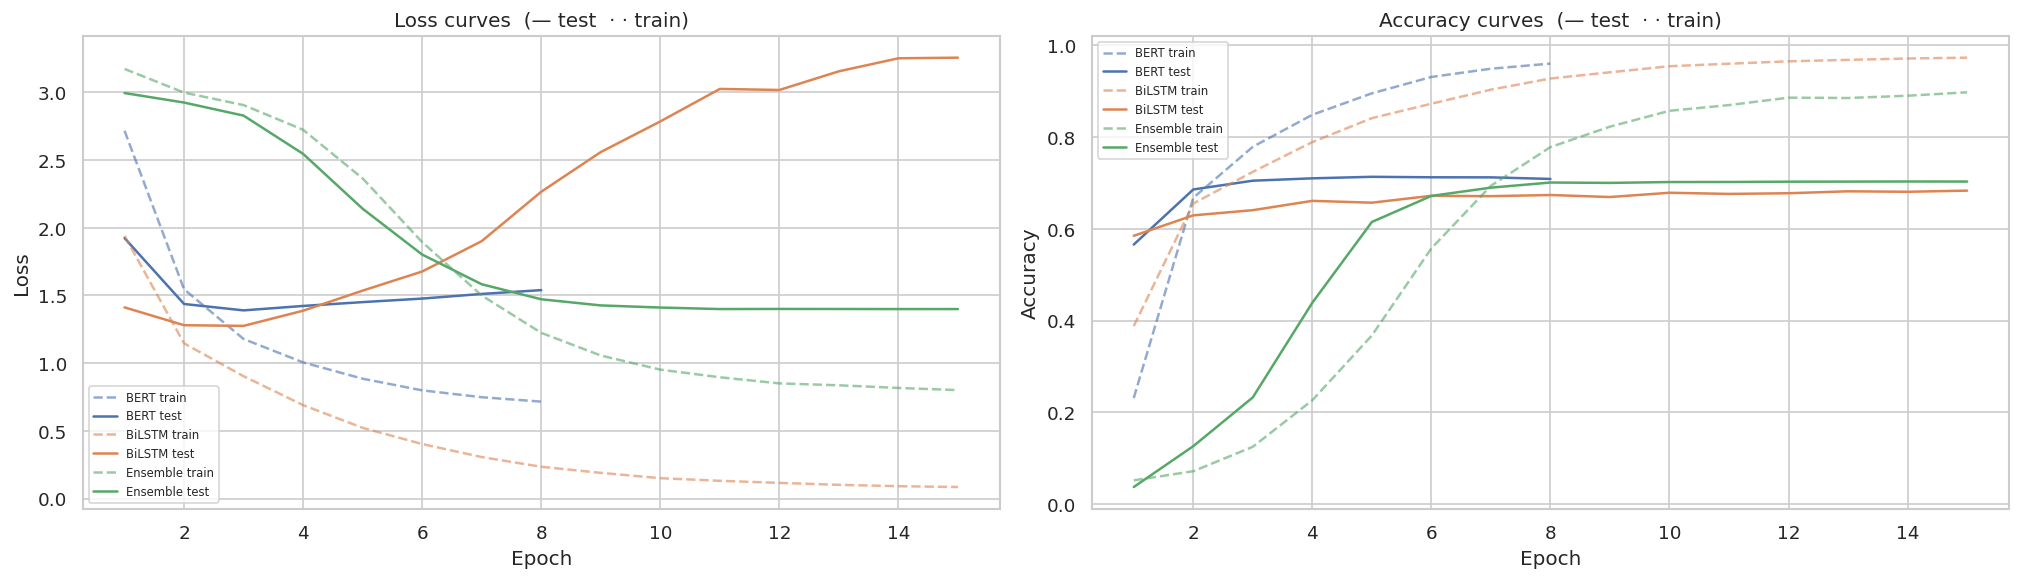

In [ ]:

# ── Cell 13: Learning curves — BERT · BiLSTM · Ensemble ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

all_hists = [
    ("BERT",     tf_history,  "C0"),
    ("BiLSTM",   rnn_history, "C1"),
    ("Ensemble", ens_history, "C2"),
]

for name, hist, color in all_hists:
    epochs = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(epochs, hist["train_loss"], "--", color=color, alpha=0.60, label=f"{name} train")
    axes[0].plot(epochs, hist["test_loss"],  "-",  color=color,             label=f"{name} test")
    axes[1].plot(epochs, hist["train_acc"],  "--", color=color, alpha=0.60, label=f"{name} train")
    axes[1].plot(epochs, hist["test_acc"],   "-",  color=color,             label=f"{name} test")

axes[0].set_title("Loss curves  (— test  · · train)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=7)

axes[1].set_title("Accuracy curves  (— test  · · train)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


## 11. Predictions and probabilities

In [ ]:

# ── Cell 14: Collect predictions — BERT · BiLSTM · Ensemble ─────────────────
import numpy as np
import torch

@torch.no_grad()
def get_predictions(model, loader, device, is_hf=False):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for batch in loader:
        batch = move_batch(batch, device)
        if is_hf:
            logits = model(input_ids=batch["input_ids"],
                           attention_mask=batch["attention_mask"]).logits
        else:
            logits = model(input_ids=batch["input_ids"],
                           attention_mask=batch["attention_mask"])

        probs = torch.softmax(logits, dim=-1)
        all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(batch["labels"].cpu().tolist())
        all_probs.append(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.vstack(all_probs)

@torch.no_grad()
def get_ensemble_predictions(meta_model, tf_logits, rnn_logits, labels, device):
    """Run the meta-learner on pre-computed logits."""
    meta_model.eval()
    combined = torch.cat([tf_logits, rnn_logits], dim=-1).to(device)
    out = meta_model(combined)
    probs = torch.softmax(out, dim=-1).cpu().numpy()
    preds = out.argmax(dim=-1).cpu().numpy()
    return preds, labels.numpy(), probs

# ── Load best checkpoints ────────────────────────────────────────────────────
if os.path.exists(TF_SAVE_PATH):
    transformer_model.load_state_dict(
        torch.load(TF_SAVE_PATH, map_location=DEVICE, weights_only=True)
    )
if os.path.exists(RNN_SAVE_PATH):
    rnn_model.load_state_dict(
        torch.load(RNN_SAVE_PATH, map_location=DEVICE, weights_only=True)
    )
if os.path.exists(ENS_SAVE_PATH):
    meta_model.load_state_dict(
        torch.load(ENS_SAVE_PATH, map_location=DEVICE, weights_only=True)
    )

transformer_model.to(DEVICE).eval()
rnn_model.to(DEVICE).eval()
meta_model.to(DEVICE).eval()

# ── Gather predictions ────────────────────────────────────────────────────────
tf_preds,  tf_labels,  tf_probs  = get_predictions(transformer_model, test_loader, DEVICE, is_hf=True)
rnn_preds, rnn_labels, rnn_probs = get_predictions(rnn_model,         test_loader, DEVICE, is_hf=False)

# Re-collect logits for ensemble
tf_logits_eval, test_labels_eval = collect_logits(transformer_model, test_loader, DEVICE, is_hf=True)
rnn_logits_eval, _               = collect_logits(rnn_model,         test_loader, DEVICE, is_hf=False)
ens_preds, ens_labels, ens_probs = get_ensemble_predictions(
    meta_model, tf_logits_eval, rnn_logits_eval, test_labels_eval, DEVICE
)

assert np.array_equal(tf_labels, rnn_labels) and np.array_equal(tf_labels, ens_labels), \
    "Label mismatch between model passes!"
labels_true = tf_labels

print(f"Collected {len(labels_true):,} test predictions.")
print(f"  BERT acc     : {(tf_preds  == labels_true).mean():.4f}")
print(f"  BiLSTM acc   : {(rnn_preds == labels_true).mean():.4f}")
print(f"  Ensemble acc : {(ens_preds == labels_true).mean():.4f}")


Collected 7,532 test predictions.
  BERT acc     : 0.7136
  BiLSTM acc   : 0.6835
  Ensemble acc : 0.7034


## 12. Summary metrics

In [ ]:

# ── Cell 15: Summary metrics (BERT, BiLSTM, Ensemble) ────────────────────────
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

all_models_preds = [
    ("BERT",     tf_preds),
    ("BiLSTM",   rnn_preds),
    ("Ensemble", ens_preds),
]

summary_rows = []
for name, preds in all_models_preds:
    summary_rows.append({
        "Model":            name,
        "Accuracy":         accuracy_score(labels_true, preds),
        "Precision_macro":  precision_score(labels_true, preds, average="macro", zero_division=0),
        "Recall_macro":     recall_score(labels_true, preds, average="macro", zero_division=0),
        "F1_macro":         f1_score(labels_true, preds, average="macro", zero_division=0),
    })

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df.style.format({
        "Accuracy":         "{:.4f}",
        "Precision_macro":  "{:.4f}",
        "Recall_macro":     "{:.4f}",
        "F1_macro":         "{:.4f}",
    }).highlight_max(subset=["Accuracy", "F1_macro"], color="lightgreen")
)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,BERT,0.7136,0.7072,0.6993,0.6995
1,BiLSTM,0.6835,0.6788,0.6716,0.6726
2,Ensemble,0.7034,0.6954,0.6890,0.6900


In [ ]:

# ── Cell 16: Per-class classification reports (BERT, BiLSTM, Ensemble) ────────
for name, preds in all_models_preds:
    print("=" * 100)
    print(f"{name.upper()} REPORT")
    print("=" * 100)
    print(classification_report(labels_true, preds, target_names=LABEL_NAMES, zero_division=0))
    print()


BERT REPORT
                          precision    recall  f1-score   support

             alt.atheism       0.44      0.46      0.45       319
           comp.graphics       0.71      0.70      0.71       389
 comp.os.ms-windows.misc       0.63      0.70      0.66       394
comp.sys.ibm.pc.hardware       0.72      0.61      0.66       392
   comp.sys.mac.hardware       0.73      0.77      0.75       385
          comp.windows.x       0.81      0.76      0.79       395
            misc.forsale       0.84      0.87      0.86       390
               rec.autos       0.54      0.77      0.63       396
         rec.motorcycles       0.69      0.79      0.74       398
      rec.sport.baseball       0.94      0.82      0.88       397
        rec.sport.hockey       0.89      0.89      0.89       399
               sci.crypt       0.79      0.73      0.76       396
         sci.electronics       0.68      0.62      0.65       393
                 sci.med       0.85      0.84      0.85       3

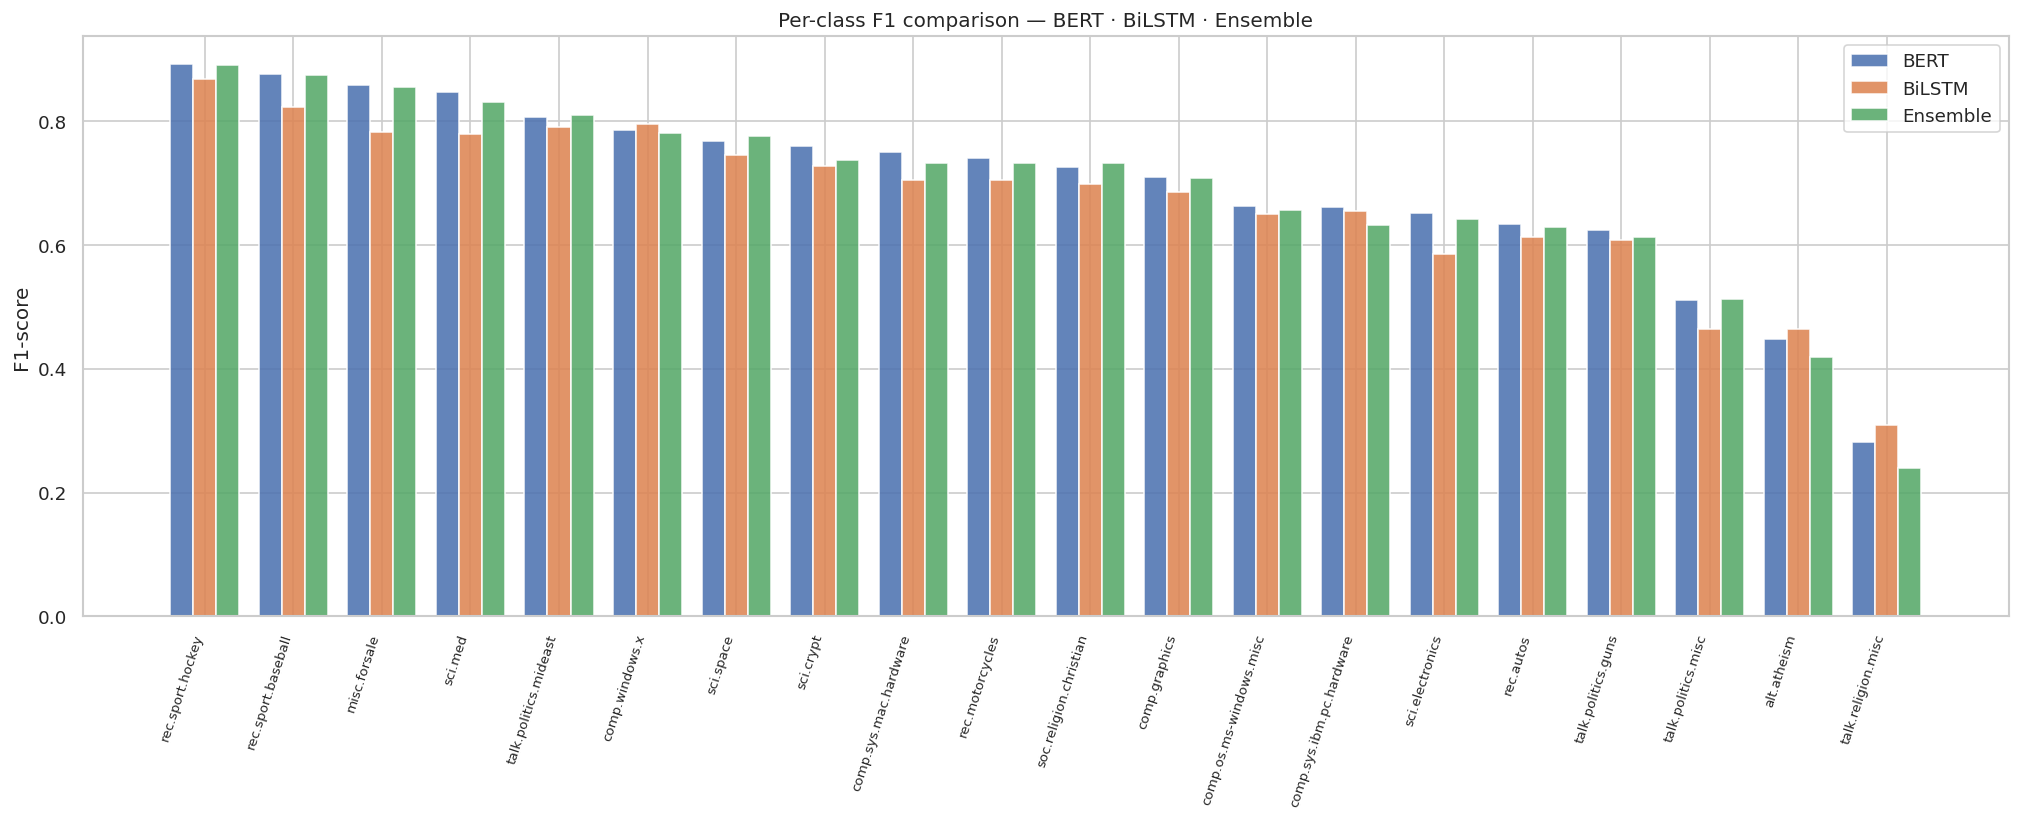

In [ ]:

# ── Cell 17: Per-class F1 comparison (BERT, BiLSTM, Ensemble) ────────────────
reports = {}
for name, preds in all_models_preds:
    reports[name] = classification_report(
        labels_true, preds, target_names=LABEL_NAMES, output_dict=True, zero_division=0
    )

f1_data = {"Class": LABEL_NAMES}
for name in reports:
    f1_data[name] = [reports[name][cls]["f1-score"] for cls in LABEL_NAMES]

sort_key = "BERT"
f1_compare = pd.DataFrame(f1_data).sort_values(sort_key, ascending=False)

plt.figure(figsize=(17, 7))
x = np.arange(len(f1_compare))
n = len(all_models_preds)
total_width = 0.78
width = total_width / n
colors = ["C0", "C1", "C2"]

for i, (name, _) in enumerate(all_models_preds):
    offset = (i - n / 2 + 0.5) * width
    plt.bar(x + offset, f1_compare[name], width=width, label=name, color=colors[i], alpha=0.87)

plt.xticks(x, f1_compare["Class"], rotation=72, ha="right", fontsize=8)
plt.ylabel("F1-score")
plt.title("Per-class F1 comparison — BERT · BiLSTM · Ensemble")
plt.legend()
plt.tight_layout()
plt.show()


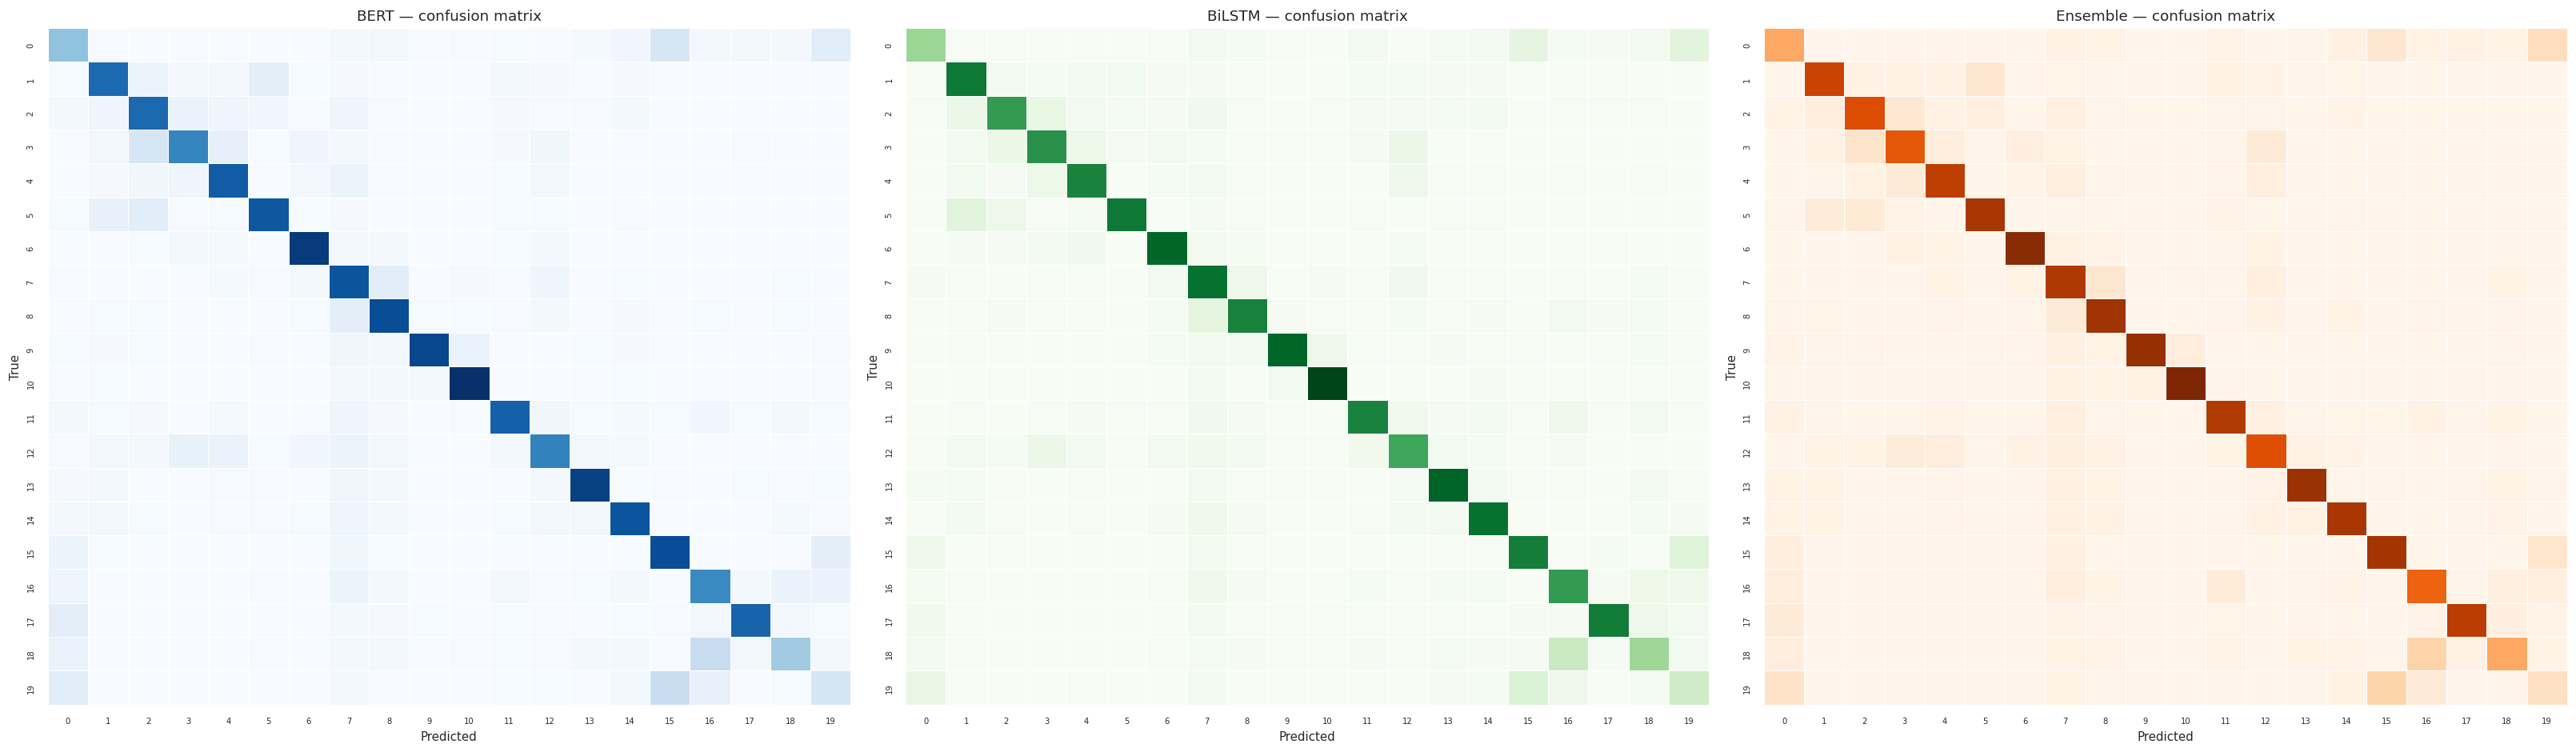

In [ ]:

# ── Cell 18: Confusion matrices (1 × 3 grid) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(27, 8))

cmaps  = ["Blues", "Greens", "Oranges"]
titles = [name for name, _ in all_models_preds]
preds_list = [preds for _, preds in all_models_preds]

for ax, preds, title, cmap in zip(axes, preds_list, titles, cmaps):
    cm = confusion_matrix(labels_true, preds)
    sns.heatmap(cm, ax=ax, cmap=cmap, cbar=False, linewidths=0.3)
    ax.set_title(f"{title} — confusion matrix", fontsize=11)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()


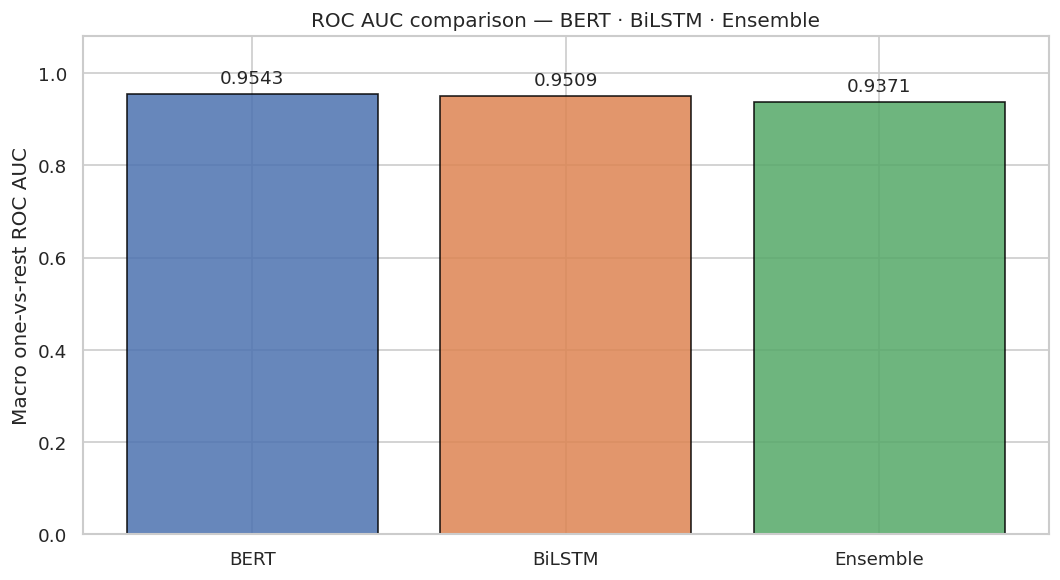

BERT            macro ROC AUC: 0.9543
BiLSTM          macro ROC AUC: 0.9509
Ensemble        macro ROC AUC: 0.9371


In [ ]:

# ── Cell 19: Macro ROC AUC comparison (BERT, BiLSTM, Ensemble) ───────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(labels_true, classes=list(range(NUM_CLASSES)))

def macro_roc_auc(y_true_bin, probs):
    aucs = []
    for i in range(y_true_bin.shape[1]):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        aucs.append(auc(fpr, tpr))
    return float(np.mean(aucs))

all_probs_list = [tf_probs, rnn_probs, ens_probs]
model_names_roc = [name for name, _ in all_models_preds]
auc_scores = [macro_roc_auc(y_true_bin, prbs) for prbs in all_probs_list]
colors_roc = ["C0", "C1", "C2"]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names_roc, auc_scores, color=colors_roc, alpha=0.85, edgecolor="black")
plt.bar_label(bars, fmt="{:.4f}", padding=4, fontsize=11)
plt.ylim(0.0, 1.08)
plt.ylabel("Macro one-vs-rest ROC AUC")
plt.title("ROC AUC comparison — BERT · BiLSTM · Ensemble")
plt.tight_layout()
plt.show()

for name, score in zip(model_names_roc, auc_scores):
    print(f"{name:<15} macro ROC AUC: {score:.4f}")


## 13. Error analysis and model size

In [ ]:

# ── Cell 20: Error analysis and model size (BERT, BiLSTM, Ensemble) ──────────
import numpy as np
import pandas as pd

def count_parameters(model, trainable_only=False):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

tf_params  = count_parameters(transformer_model)
rnn_params = count_parameters(rnn_model)

all_models_info = [
    ("BERT",     tf_preds,  tf_params),
    ("BiLSTM",   rnn_preds, rnn_params),
    ("Ensemble", ens_preds, tf_params + rnn_params),
]

comparison_rows = []
for name, preds, n_params in all_models_info:
    wrong_idx = np.where(preds != labels_true)[0]
    comparison_rows.append({
        "Model":      name,
        "Parameters": n_params,
        "Errors":     int(len(wrong_idx)),
        "Accuracy":   float((preds == labels_true).mean()),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

# ── Sample mistakes for each model ────────────────────────────────────────────
for name, preds, _ in all_models_info:
    wrong_idx = np.where(preds != labels_true)[0][:3]
    print(f"\n{'─'*80}")
    print(f"Sample {name} mistakes")
    print(f"{'─'*80}")
    for idx in wrong_idx:
        print(f"True label : {LABEL_NAMES[labels_true[idx]]}")
        print(f"Pred label : {LABEL_NAMES[preds[idx]]}")
        raw_text = test_df.iloc[idx]["text"]
        print(f"Text       : {str(raw_text)[:300]}")
        print()


,Model,Parameters,Errors,Accuracy
0,BERT,109497620,2157,0.713622
1,BiLSTM,31232661,2384,0.683484
2,Ensemble,140730281,2234,0.703399



────────────────────────────────────────────────────────────────────────────────
Sample BERT mistakes
────────────────────────────────────────────────────────────────────────────────
True label : alt.atheism
Pred label : talk.politics.misc
Text       : 
In a word, yes.


True label : talk.politics.mideast
Pred label : alt.atheism
Text       : 
They were attacking the Iraqis to drive them out of Kuwait,
a country whose citizens have close blood and business ties
to Saudi citizens.  And me thinks if the US had not helped out
the Iraqis would have swallowed Saudi Arabia, too (or at 
least the eastern oilfields).  And no Muslim country was d

True label : talk.religion.misc
Pred label : alt.atheism
Text       : 
I've just spent two solid months arguing that no such thing as an
objective moral system exists.


────────────────────────────────────────────────────────────────────────────────
Sample BiLSTM mistakes
──────────────────────────────────────────────────────────────────────────────

## 14. Save metadata for later inference

In [ ]:

# ── Cell 21: Save metadata ────────────────────────────────────────────────────
model_meta = {
    "bert_model_name":        BERT_MODEL_NAME,
    "max_seq_len":            MAX_SEQ_LEN,
    "num_classes":            NUM_CLASSES,
    "label_names":            LABEL_NAMES,
    "transformer_checkpoint": TF_SAVE_PATH,
    "rnn_checkpoint":         RNN_SAVE_PATH,
    "ensemble_checkpoint":    ENS_SAVE_PATH,
    "rnn_architecture": {
        "type": "PretrainedBiLSTMClassifier",
        "hidden_size": 384,
        "num_layers": 2,
        "dropout": 0.3,
    },
}

with open("model_meta.json", "w", encoding="utf-8") as f:
    json.dump(model_meta, f, ensure_ascii=False, indent=2)

print("Saved: model_meta.json")
print(f"  bert_model_name        : {BERT_MODEL_NAME}")
print(f"  transformer_checkpoint : {TF_SAVE_PATH}")
print(f"  rnn_checkpoint         : {RNN_SAVE_PATH}")
print(f"  ensemble_checkpoint    : {ENS_SAVE_PATH}  (meta-MLP weights only)")


Saved: model_meta.json
  bert_model_name        : bert-base-uncased
  transformer_checkpoint : transformer_gpu_safe.pt
  rnn_checkpoint         : rnn_gpu_safe.pt
  ensemble_checkpoint    : ensemble.pt  (meta-MLP weights only)


## 15. Inference demo

In [ ]:

# ── Cell 22: Inference demo (BERT · BiLSTM · Ensemble) ───────────────────────
transformer_model.to(DEVICE).eval()
rnn_model.to(DEVICE).eval()
meta_model.to(DEVICE).eval()

def predict_single(text, model, tok, device, is_hf=False):
    """Predict class probabilities for a single text."""
    enc = tok(text, max_length=MAX_SEQ_LEN, padding="max_length",
              truncation=True, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)
    attn_mask = enc["attention_mask"].to(device)
    with torch.no_grad():
        if is_hf:
            logits = model(input_ids=input_ids, attention_mask=attn_mask).logits
        else:
            logits = model(input_ids=input_ids, attention_mask=attn_mask)
    return torch.softmax(logits, dim=-1).squeeze(0).cpu()

examples = [
    ("Space",    "NASA announced a new mission to study Jupiter and its moons."),
    ("Hardware", "My graphics card driver keeps crashing when I install the new kernel."),
    ("Baseball", "The pitcher threw a complete game shutout and the team won 4 to 0."),
    ("Religion", "The church community discussed faith, redemption, and prayer this Sunday."),
    ("Politics", "The senator proposed new legislation on healthcare and tax reform."),
    ("Medicine", "Researchers found a new drug that reduces inflammation in arthritis patients."),
]

MODEL_COLS = ["BERT", "BiLSTM", "Ensemble"]
COL_W = 34

header_parts = [f"{'Category':<18}"] + [f"{n:<{COL_W}}" for n in MODEL_COLS]
print("  ".join(header_parts))
print("─" * (18 + 2 * len(MODEL_COLS) + COL_W * len(MODEL_COLS)))

for category, text in examples:
    tf_p  = predict_single(text, transformer_model, tokenizer, DEVICE, is_hf=True)
    rnn_p = predict_single(text, rnn_model,         tokenizer, DEVICE, is_hf=False)

    # Ensemble: feed logits through meta-MLP
    enc = tokenizer(text, max_length=MAX_SEQ_LEN, padding="max_length",
                    truncation=True, return_tensors="pt")
    ids  = enc["input_ids"].to(DEVICE)
    mask = enc["attention_mask"].to(DEVICE)
    with torch.no_grad():
        la = transformer_model(input_ids=ids, attention_mask=mask).logits
        lb = rnn_model(input_ids=ids, attention_mask=mask)
        ens_logits = meta_model(torch.cat([la, lb], dim=-1))
        ens_p = torch.softmax(ens_logits, dim=-1).squeeze(0).cpu()

    row = [f"{category:<18}"]
    for probs in [tf_p, rnn_p, ens_p]:
        top_idx   = int(probs.argmax().item())
        top_label = LABEL_NAMES[top_idx]
        top_score = float(probs[top_idx].item())
        row.append(f"{top_label} ({top_score:.2f})".ljust(COL_W))

    print("  ".join(row))


Category            BERT                                BiLSTM                              Ensemble                          
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Space               sci.space (0.92)                    sci.space (1.00)                    sci.space (0.95)                  
Hardware            comp.os.ms-windows.misc (0.30)      comp.sys.mac.hardware (0.92)        comp.graphics (0.27)              
Baseball            rec.sport.baseball (0.91)           rec.sport.baseball (1.00)           rec.sport.baseball (0.87)         
Religion            soc.religion.christian (0.87)       soc.religion.christian (1.00)       soc.religion.christian (0.88)     
Politics            talk.politics.misc (0.92)           talk.politics.misc (1.00)           talk.politics.misc (0.79)         
Medicine            sci.med (0.93)                      sci.med (1.00)                      sci.med (0.86)     